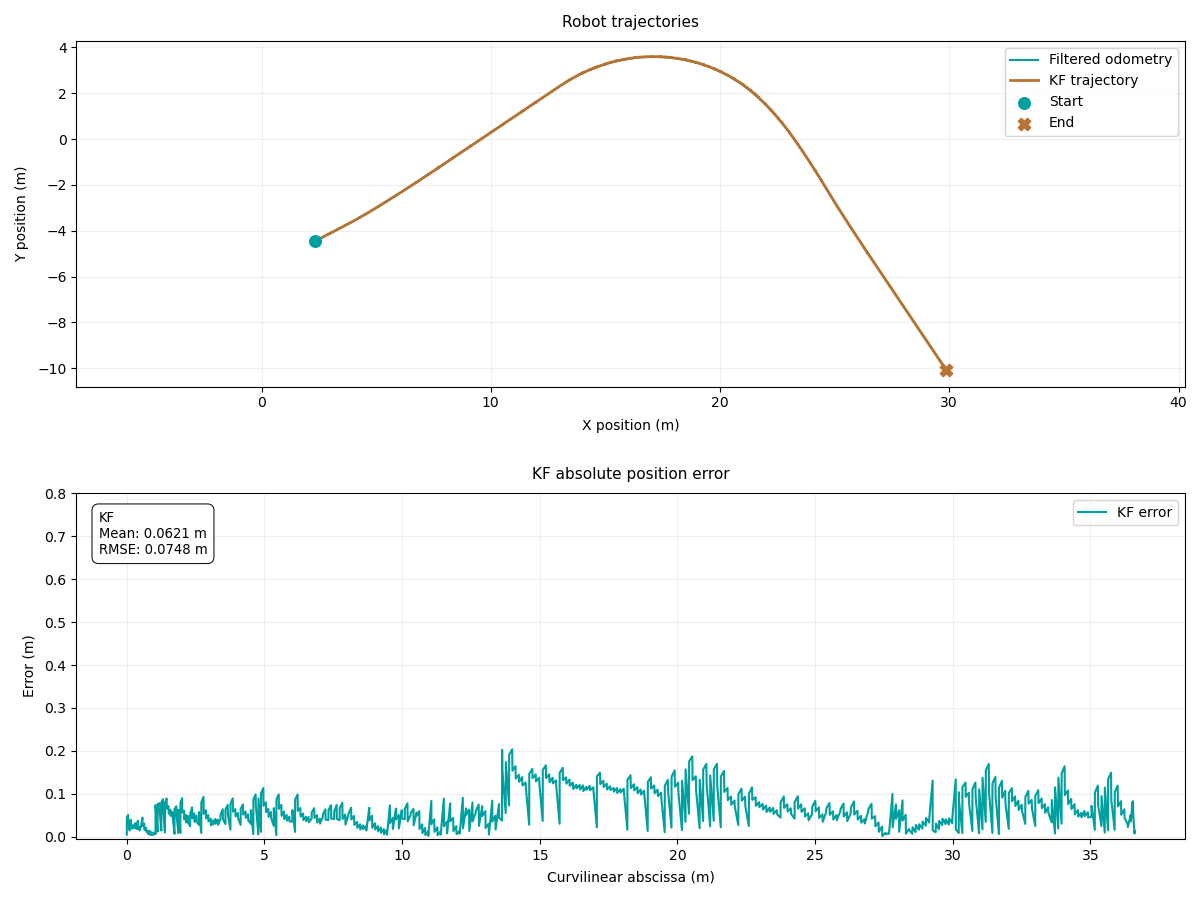

In [1]:
# %matplotlib inline
%matplotlib widget

import os
import math
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD AND PROCESS DATA (CLEAN & SIMPLE)
# ============================================================
transient_distance = 1.0  # meter

# Color palette from your reference figure layout
COLOR_CYAN = "#00A0A0"   # Clean matte cyan
COLOR_BROWN = "#B87333"  # Copper brown

# Load raw numpy tracking dumps
est = np.load("est_with_time.npy")
filt = np.load("filt_with_time.npy")

if est.size == 0:
    raise ValueError("est_with_time.npy is empty.")

if filt.size == 0:
    raise ValueError("filt_with_time.npy is empty.")

# Synchronize timestamps sorting
est = est[np.argsort(est[:, 0])]
filt = filt[np.argsort(filt[:, 0])]

# Keep common overlapping flight paths interval
valid_time = (est[:, 0] >= filt[0, 0]) & (est[:, 0] <= filt[-1, 0])
t_est = est[valid_time, 0]
x_est = est[valid_time, 1]
y_est = est[valid_time, 2]

# Synchronize odometry tracking data onto KF timeline
x_filt_interp = np.interp(t_est, filt[:, 0], filt[:, 1])
y_filt_interp = np.interp(t_est, filt[:, 0], filt[:, 2])

# Compute continuous curvilinear abscissa path progression
ds = np.sqrt(np.diff(x_filt_interp)**2 + np.diff(y_filt_interp)**2)
s_ref = np.concatenate(([0.0], np.cumsum(ds)))

# Bypass early initial transient initialization settling distance
valid_dist = s_ref >= transient_distance
x_est, y_est = x_est[valid_dist], y_est[valid_dist]
x_filt_i, y_filt_i = x_filt_interp[valid_dist], y_filt_interp[valid_dist]
s_ref = s_ref[valid_dist] - s_ref[valid_dist][0]

# Compute true mathematical absolute Euclidean position tracking error
error_kf_odom = np.sqrt((x_est - x_filt_i)**2 + (y_filt_i - y_est)**2)

# Calculate final error statistics logs
mean_err = np.mean(error_kf_odom)
rmse_err = np.sqrt(np.mean(error_kf_odom**2))

# Updated plain text statistics formatting for KF
stats_text = (
    "KF\n"
    f"Mean: {mean_err:.4f} m\n"
    f"RMSE: {rmse_err:.4f} m"
)

# ============================================================
# 2. PLOTTING WITH MATCHED DESIGN PROFILE
# ============================================================
os.makedirs("figure_dog", exist_ok=True)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

# ---------------------------------
# Top Plot: Trajectories Matching Style
# ---------------------------------
ax1.plot(x_filt_i, y_filt_i, color=COLOR_CYAN, linewidth=1.5, label="Filtered odometry")
ax1.plot(x_est, y_est, color=COLOR_BROWN, linewidth=2.0, label="KF trajectory ")

# Start and end landmarks layout
ax1.scatter(x_filt_i[0], y_filt_i[0], color=COLOR_CYAN, marker="o", s=70, zorder=5, label="Start")
ax1.scatter(x_filt_i[-1], y_filt_i[-1], color=COLOR_BROWN, marker="X", s=80, zorder=5, label="End")

ax1.set_title("Robot trajectories", fontsize=11, pad=10)
ax1.set_xlabel("X position (m)", labelpad=6)
ax1.set_ylabel("Y position (m)", labelpad=6)
ax1.axis("equal")
ax1.grid(True, alpha=0.2)
ax1.legend(loc="upper right", frameon=True)

# ---------------------------------
# Bottom Plot: Clean Error Curve
# ---------------------------------
ax2.plot(s_ref, error_kf_odom, color=COLOR_CYAN, linewidth=1.5, label="KF error")

# --- CALIBRATED VERTICAL AXIS SCALE ---
# Set to 0.80 so the error curve is clearly visible and clean
ax2.set_ylim(-0.005, 0.80) 

ax2.set_title("KF absolute position error", fontsize=11, pad=10)
ax2.set_xlabel("Curvilinear abscissa (m)", labelpad=6)
ax2.set_ylabel("Error (m)", labelpad=6)
ax2.grid(True, alpha=0.2)
ax2.legend(loc="upper right", frameon=True)

# Overlay dynamic text summary block on the left side WITH border box enabled
ax2.text(
    0.02, 0.95, stats_text, transform=ax2.transAxes,
    verticalalignment="top", horizontalalignment="left", 
    fontsize=9.5, color="black",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 0.8,
        "alpha": 0.9
    }
)

plt.tight_layout(h_pad=2.5)
plt.savefig("figure_dog/kf_error_curvilinear_abscissa.pdf", bbox_inches="tight", pad_inches=0.15)
plt.show()



Graphique sauvegardé avec succès dans : figure_dog/kf_dual_error_comparison.pdf


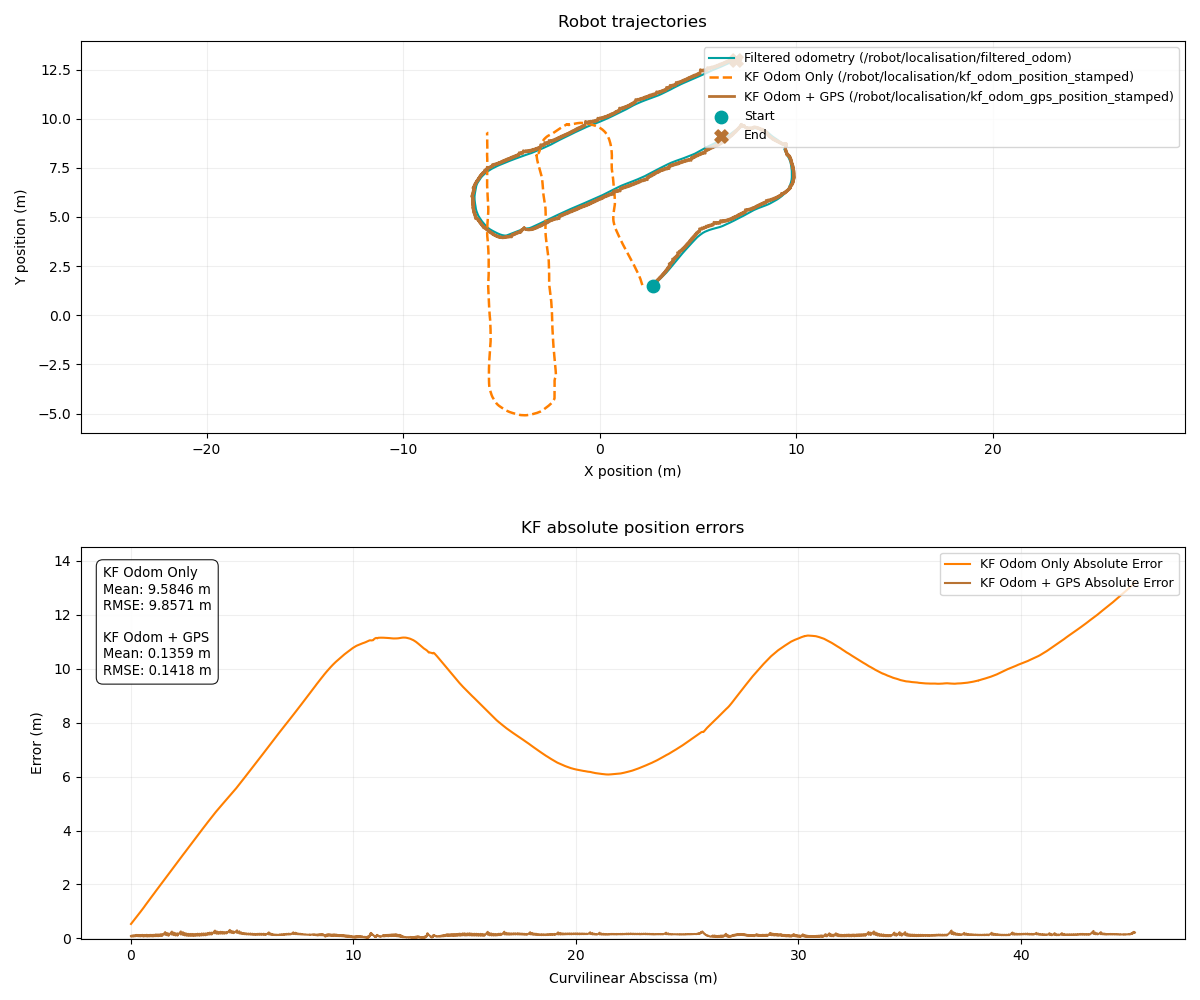

In [2]:
# %matplotlib inline
%matplotlib widget

import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ============================================================
transient_distance = 1.0  # Distance de transition initiale (mètres)

# Palette de couleurs du profil graphique de référence
COLOR_CYAN = "#00A0A0"    # Cyan mat propre pour la référence
COLOR_BROWN = "#B87333"   # Brun cuivre pour le KF complet (Odom + GPS)
COLOR_PURPLE = "#FF7F00"  # Orange pour le KF Odométrie seule

# Chargement des fichiers extraits de votre rosbag (Spécifiques au KF)
try:
    odom_data = np.load("kf_odom_with_time.npy")
    odom_gps_data = np.load("kf_odom_gps_with_time.npy")
    filt_data = np.load("filt_with_time.npy")
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Erreur de chargement : assurez-vous d'avoir exécuté le script "
        f"d'extraction au préalable dans ce répertoire. Détail : {e}"
    )

# Synchronisation et tri chronologique par sécurité
odom_data = odom_data[np.argsort(odom_data[:, 0])]
odom_gps_data = odom_gps_data[np.argsort(odom_gps_data[:, 0])]
filt_data = filt_data[np.argsort(filt_data[:, 0])]

# Détermination de l'intervalle de temps partagé par toutes les sources
common_start = max(odom_data[0, 0], odom_gps_data[0, 0], filt_data[0, 0])
common_end = min(odom_data[-1, 0], odom_gps_data[-1, 0], filt_data[-1, 0])

# Masques pour filtrer uniquement la zone temporelle commune
valid_odom = (odom_data[:, 0] >= common_start) & (odom_data[:, 0] <= common_end)
valid_gps = (odom_gps_data[:, 0] >= common_start) & (odom_gps_data[:, 0] <= common_end)

t_odom = odom_data[valid_odom, 0]
x_odom = odom_data[valid_odom, 1]
y_odom = odom_data[valid_odom, 2]

t_gps = odom_gps_data[valid_gps, 0]
x_gps = odom_gps_data[valid_gps, 1]
y_gps = odom_gps_data[valid_gps, 2]

# Synchronisation (interpolation) des données sur une ligne temporelle commune (celle du GPS)
x_filt_interp = np.interp(t_gps, filt_data[:, 0], filt_data[:, 1])
y_filt_interp = np.interp(t_gps, filt_data[:, 0], filt_data[:, 2])

x_odom_interp = np.interp(t_gps, t_odom, x_odom)
y_odom_interp = np.interp(t_gps, t_odom, y_odom)

# Calcul de l'abscisse curviligne le long de la trajectoire de référence (filt)
ds = np.sqrt(np.diff(x_filt_interp)**2 + np.diff(y_filt_interp)**2)
s_ref = np.concatenate(([0.0], np.cumsum(ds)))

# Retrait du régime transitoire initial basé sur la distance définie
valid_dist = s_ref >= transient_distance

x_filt_final = x_filt_interp[valid_dist]
y_filt_final = y_filt_interp[valid_dist]

x_gps_final = x_gps[valid_dist]
y_gps_final = y_gps[valid_dist]

x_odom_final = x_odom_interp[valid_dist]
y_odom_final = y_odom_interp[valid_dist]

s_ref_final = s_ref[valid_dist] - s_ref[valid_dist][0]

# ============================================================
# 2. CALCUL DES ERREURS ABSOLUES ET STATISTIQUES
# ============================================================
# Erreur 1 : KF Odométrie seule par rapport à la référence filtrée
error_odom_only = np.sqrt((x_odom_final - x_filt_final)**2 + (y_odom_final - y_filt_final)**2)

# Erreur 2 : KF Odométrie + GPS par rapport à la référence filtrée
error_odom_gps = np.sqrt((x_gps_final - x_filt_final)**2 + (y_filt_final - y_gps_final)**2)

# Calcul des indicateurs statistiques (Moyenne & RMSE)
mean_err_odom = np.mean(error_odom_only)
rmse_err_odom = np.sqrt(np.mean(error_odom_only**2))

mean_err_gps = np.mean(error_odom_gps)
rmse_err_gps = np.sqrt(np.mean(error_odom_gps**2))

# Mise en forme du bloc de texte statistique unifié adapté pour le KF
stats_text = (
    "KF Odom Only\n"
    f"Mean: {mean_err_odom:.4f} m\n"
    f"RMSE: {rmse_err_odom:.4f} m\n\n"
    "KF Odom + GPS\n"
    f"Mean: {mean_err_gps:.4f} m\n"
    f"RMSE: {rmse_err_gps:.4f} m"
)

# ============================================================
# 3. GÉNÉRATION DES GRAPHIQUES (MATPLOTLIB)
# ============================================================
os.makedirs("figure_dog", exist_ok=True)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --------------------------------------------------------
# Graphique Supérieur : Comparaison Spatiale des Trajectoires
# --------------------------------------------------------
# Tracé de la référence
ax1.plot(x_filt_final, y_filt_final, color=COLOR_CYAN, linewidth=1.5, 
         label="Filtered odometry (/robot/localisation/filtered_odom)")

# Tracé du KF sans GPS (Prédiction seule)
ax1.plot(x_odom_final, y_odom_final, color=COLOR_PURPLE, linewidth=1.8, linestyle="--",
         label="KF Odom Only (/robot/localisation/kf_odom_position_stamped)")

# Tracé du KF complet (Avec correction GPS)
ax1.plot(x_gps_final, y_gps_final, color=COLOR_BROWN, linewidth=2.0, 
         label="KF Odom + GPS (/robot/localisation/kf_odom_gps_position_stamped)")

# Marquage des points de départ et d'arrivée
ax1.scatter(x_filt_final[0], y_filt_final[0], color=COLOR_CYAN, marker="o", s=80, zorder=5, label="Start")
ax1.scatter(x_filt_final[-1], y_filt_final[-1], color=COLOR_BROWN, marker="X", s=90, zorder=5, label="End")

ax1.set_title("Robot trajectories", fontsize=12, pad=10)
ax1.set_xlabel("X position (m)", labelpad=6)
ax1.set_ylabel("Y position (m)", labelpad=6)
ax1.axis("equal")
ax1.grid(True, alpha=0.2)
ax1.legend(loc="upper right", frameon=True, fontsize=9)

# --------------------------------------------------------
# Graphique Inférieur : Évolution Temporelle des Erreurs
# --------------------------------------------------------
# Courbe d'erreur KF Odométrie seule
ax2.plot(s_ref_final, error_odom_only, color=COLOR_PURPLE, linewidth=1.5, 
         label="KF Odom Only Absolute Error")

# Courbe d'erreur KF Complet (Odom + GPS)
ax2.plot(s_ref_final, error_odom_gps, color=COLOR_BROWN, linewidth=1.5, 
         label="KF Odom + GPS Absolute Error")

# Configuration de l'axe vertical pour englober la dérive odométrique
max_error_observed = max(np.max(error_odom_only), np.max(error_odom_gps))
ax2.set_ylim(-0.02, max_error_observed * 1.1)

ax2.set_title("KF absolute position errors", fontsize=12, pad=10)
ax2.set_xlabel("Curvilinear Abscissa (m)", labelpad=6)
ax2.set_ylabel("Error (m)", labelpad=6)
ax2.grid(True, alpha=0.2)
ax2.legend(loc="upper right", frameon=True, fontsize=9)

# Incrustation de l'encadré contenant les métriques statistiques globales
ax2.text(
    0.02, 0.95, stats_text, transform=ax2.transAxes,
    verticalalignment="top", horizontalalignment="left", 
    fontsize=9.5, color="black",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 0.8,
        "alpha": 0.9
    }
)

# Ajustement de la géométrie et sauvegarde au format PDF vectoriel
plt.tight_layout(h_pad=3.0)
output_path = "figure_dog/kf_dual_error_comparison.pdf"
plt.savefig(output_path, bbox_inches="tight", pad_inches=0.15)
print(f"\nGraphique sauvegardé avec succès dans : {output_path}")
plt.show()
